In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sahilhussain2410/ev-dataset-model/model_data.csv
/kaggle/input/datasets/sahilhussain2410/ev-vehicles-preprocess-ds/preprocess_ds/cleaned_data.csv
/kaggle/input/datasets/sahilhussain2410/ev-vehicles-preprocess-ds/preprocess_ds/urban_grid_hour.csv
/kaggle/input/datasets/sahilhussain2410/ev-vehicles-preprocess-ds/preprocess_ds/acn_station_hour.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [4]:
model_data = pd.read_csv(
    "/kaggle/input/datasets/sahilhussain2410/ev-dataset-model/model_data.csv",
    parse_dates=["hour"]
)

In [5]:
model_data = model_data.sort_values(
    "hour"
)

In [6]:
n = len(model_data)

train_end = int(0.70 * n)

valid_end = int(0.85 * n)

In [7]:
train_df = model_data.iloc[:train_end]

valid_df = model_data.iloc[
    train_end:valid_end
]

test_df = model_data.iloc[
    valid_end:
]

In [8]:
features = [

    # temporal
    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "month",
    "peak_hour_flag",

    # infrastructure
    "charger_count",
    "fast_count",
    "slow_count",
    "CBD",
    "dynamic_pricing",

    # # demand history
    # #"demand_lag_1",
    # #"demand_lag_24",
    # #"rolling_mean_3",
    # "rolling_mean_24",
    # "rolling_std_24",

    # # utilization history
    # "util_lag_24",
    # "util_rolling_24",

    # # pricing
    # "price",
    # "price_lag_1",
    # "price_change",
    # "price_ratio",

    # ratios
    "fast_ratio",
    "slow_ratio"
]

In [9]:
features

['hour_of_day',
 'day_of_week',
 'is_weekend',
 'month',
 'peak_hour_flag',
 'charger_count',
 'fast_count',
 'slow_count',
 'CBD',
 'dynamic_pricing',
 'fast_ratio',
 'slow_ratio']

In [10]:
X_train = train_df[features]
y_train = train_df["target_demand"]

X_valid = valid_df[features]
y_valid = valid_df["target_demand"]

X_test = test_df[features]
y_test = test_df["target_demand"]

In [11]:
lgbm = LGBMRegressor(
    objective="regression",

    n_estimators=500,

    learning_rate=0.05,

    max_depth=8,

    num_leaves=63,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

In [12]:
lgbm.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010474 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 481
[LightGBM] [Info] Number of data points in the train set: 120338, number of used features: 12
[LightGBM] [Info] Start training from score 425.982634


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, max_depth=8,
              n_estimators=500, num_leaves=63, objective='regression',
              random_state=42, subsample=0.8)

In [13]:
valid_pred = lgbm.predict(
    X_valid
)

In [14]:
print(valid_pred[1:10])

[3153.29856281  409.64014941   62.10101981  152.7633843    14.36368496
   79.66282473   92.9260192   225.7480634    67.80507017]


In [15]:
rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        valid_pred
    )
)

mae = mean_absolute_error(
    y_valid,
    valid_pred
)

r2 = r2_score(
    y_valid,
    valid_pred
)

print(rmse)
print(mae)
print(r2)

374.48002106911724
114.82093806245496
0.910078329479953


# with advanced engineered features

In [16]:
features = [

    # temporal
    "hour_of_day",
    "day_of_week",
    "is_weekend",
    "month",
    "peak_hour_flag",

    # infrastructure
    "charger_count",
    "fast_count",
    "slow_count",
    "CBD",
    "dynamic_pricing",

    # demand history
    "demand_lag_1",
    "demand_lag_24",
    "rolling_mean_24",
    "rolling_std_24",

    # utilization history
    "util_lag_24",
    "util_rolling_24",

    # pricing
    "price",
    "price_lag_1",
    "price_change",
    "price_ratio",

    # ratios
    "fast_ratio",
    "slow_ratio"
]

In [17]:
X_train = train_df[features]
y_train = train_df["target_demand"]

X_valid = valid_df[features]
y_valid = valid_df["target_demand"]

X_test = test_df[features]
y_test = test_df["target_demand"]

In [18]:
lgbm = LGBMRegressor(
    objective="regression",

    n_estimators=500,

    learning_rate=0.05,

    max_depth=8,

    num_leaves=63,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

In [19]:
lgbm.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3009
[LightGBM] [Info] Number of data points in the train set: 120338, number of used features: 22
[LightGBM] [Info] Start training from score 425.982634
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, max_depth=8,
              n_estimators=500, num_leaves=63, objective='regression',
              random_state=42, subsample=0.8)

In [20]:
valid_pred = lgbm.predict(
    X_valid
)

In [21]:
rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        valid_pred
    )
)

mae = mean_absolute_error(
    y_valid,
    valid_pred
)

r2 = r2_score(
    y_valid,
    valid_pred
)

print(rmse)
print(mae)
print(r2)

188.19715947483107
59.554998772975416
0.9772891604178215


# train on full train


In [22]:
train_full = pd.concat(
    [
        train_df,
        valid_df
    ]
)

In [23]:
X_train1=train_full[features]
y_train1=train_full['target_demand']

In [24]:
lgbm.fit(X_train1,y_train1)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012537 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3016
[LightGBM] [Info] Number of data points in the train set: 146125, number of used features: 22
[LightGBM] [Info] Start training from score 433.916611
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, max_depth=8,
              n_estimators=500, num_leaves=63, objective='regression',
              random_state=42, subsample=0.8)

In [25]:
test_pred=lgbm.predict(X_test)

In [26]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)

mae = mean_absolute_error(
    y_test,
    test_pred
)

r2 = r2_score(
    y_test,
    test_pred
)

print(rmse)
print(mae)
print(r2)

181.70809960101283
59.120417963723206
0.9792297479161971


In [27]:
importance = pd.DataFrame({

    "feature":
        features,

    "importance":
        lgbm.feature_importances_
})

In [28]:
importance = (
    importance
    .sort_values(
        "importance",
        ascending=False
    )
)

,feature,importance
14,util_lag_24,3526
10,demand_lag_1,3299
0,hour_of_day,3110
15,util_rolling_24,2957
11,demand_lag_24,2952
1,day_of_week,2006
13,rolling_std_24,1886
12,rolling_mean_24,1513
19,price_ratio,1451
18,price_change,1333


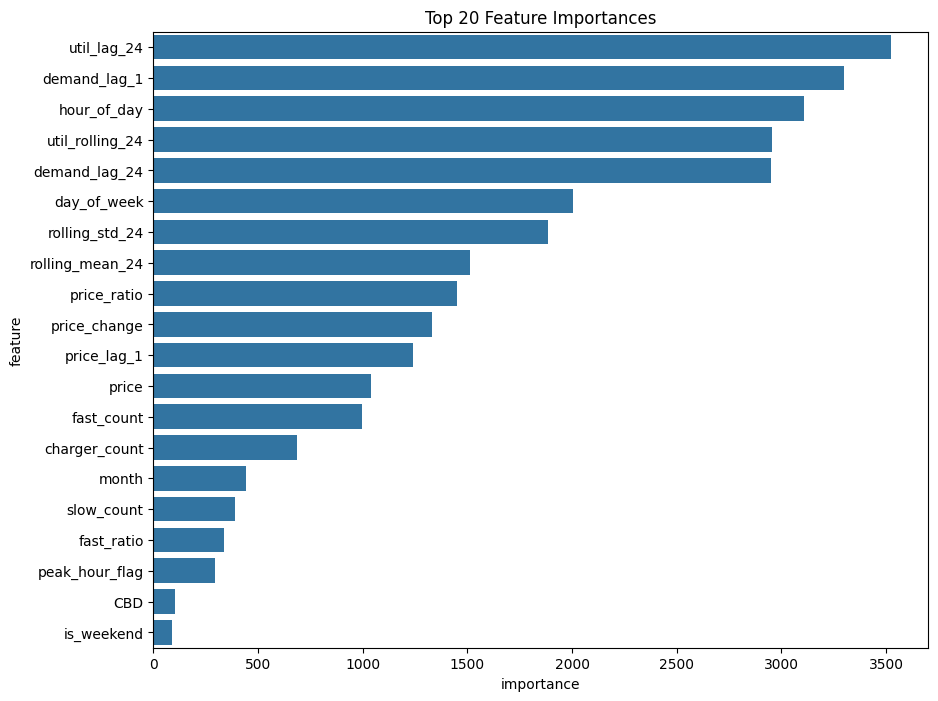

In [29]:
plt.figure(figsize=(10,8))
display(importance.head(10))
sns.barplot(
    data=importance.head(20),

    x="importance",

    y="feature"
)

plt.title(
    "Top 20 Feature Importances"
)

plt.show()

In [30]:
import shap
explainer = shap.TreeExplainer(
    lgbm
)

shap_values = (
    explainer.shap_values(
        X_test.sample(
            5000,
            random_state=42
        )
    )
)

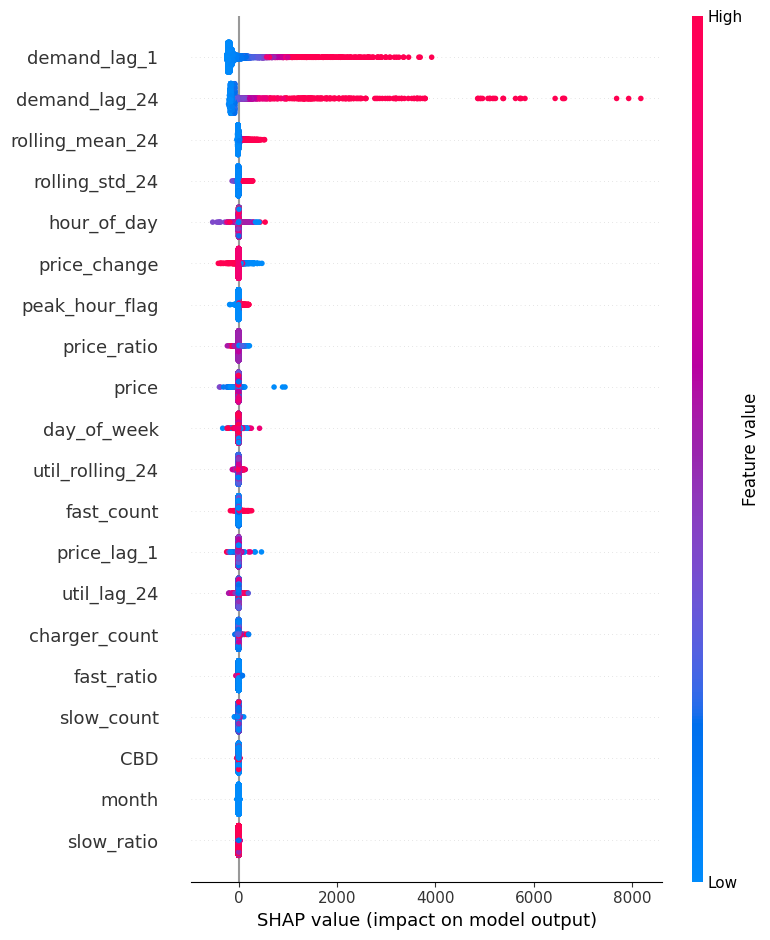

In [31]:
shap.summary_plot(
    shap_values,
    X_test.sample(
        5000,
        random_state=42
    )
)

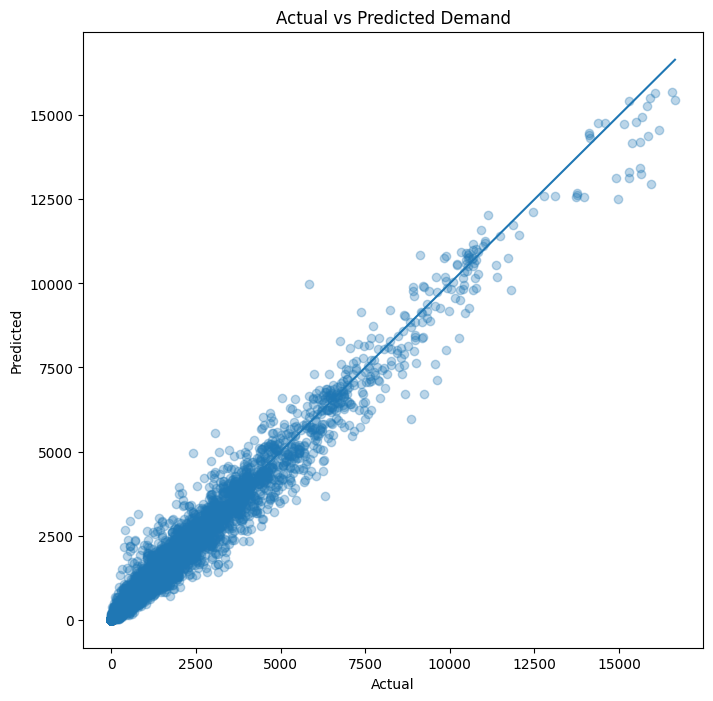

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(
    y_valid,
    valid_pred,
    alpha=0.3
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted Demand"
)

plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()]
)

plt.show()

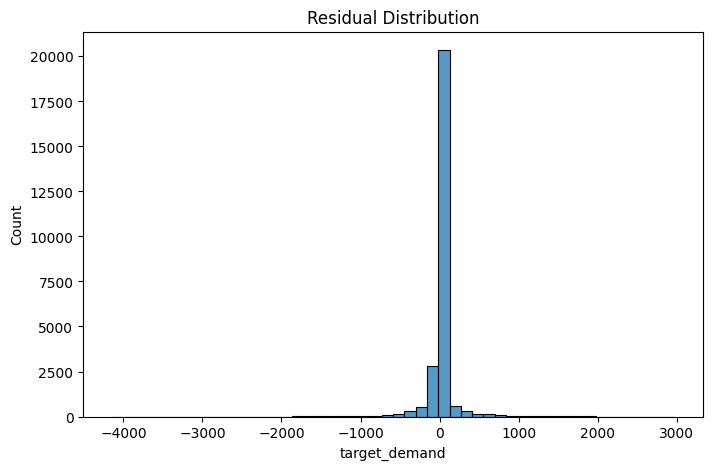

In [33]:
residuals = y_valid - valid_pred
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=50
)

plt.title(
    "Residual Distribution"
)

plt.show()